# 90deg_bend_Example — 90° 弯转: 3D 二极场, 分段追踪

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "90deg_bend_Example"
STEM = "Section1"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: 90deg_bend_Example | 物理: 90° 弯转: 3D 二极场, 分段追踪


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                         19. 8.2026  21:34

     Parameter file is:  Section1.in                                       
     90 degree bend section 1                                                        

 Initialize element settings:
     neglecting space charge forces 

 --------------------------------------------------------------------------
 Cavity:

     Reading cavity field data from:      3D_Dipole                                                                       
     Cavity Frequency               f =    0.000     GHz
     3D magnetic field length             0.4500     m
     Number of periods                      1
     3D Section starts at                -0.3000     m
     3D Section ends at  

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: Section1.0100.001

  90deg_bend_Example @ Section1.0100.001
  Particles:              7 total,        7 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        0.0700 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:       1.8680 MeV/c
  Ref. kinetic E:      1.4256 MeV
  gamma:               3.7899
  beta:              0.964561
----------------------------------------
  Centroid x:        112.4730 mm
  Centroid y:          0.0000 mm
  Centroid z:         -0.0000 mm
  sigma_x:             0.4058 mm
  sigma_y:             0.0000 mm
  sigma_z:             0.4550 mm
----------------------------------------
  Mean pz:             1.8680 MeV/c
  sigma_p/p:         0.015409
  Mean E_kin:          3.4967 MeV
  sigma_E:            21.1800 keV
  sigma_E/E:         0.006057
----------------------------------------
  eps_x (geom):        0.0153 um.rad
  eps_y (geom):        0.0000 um.rad
  eps_nx:       

quantity,value,unit
n_particle,7,
n_active,7,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,0.07 (|Q|),nC
mean_x_mm,112.473,mm
mean_y_mm,0,mm
mean_z_mm,-1.3604e-05,mm
sig_x_mm,0.4058,mm


### 示例要点

分段追踪: Section1 追踪到弯转入口, Section2 用 3D 二极场完成 90°
弯转。注意: 本例的输入 test.ini 只有 **7 个探针粒子** (DESY 官方
如此设计 — 这是轨迹演示算例), 所以相空间图里点很少是正常现象,
本例重点是下面的 3D 二极场截面与分段 Log。想看"满粒子"相空间请
看 Manual_Example.ipynb。

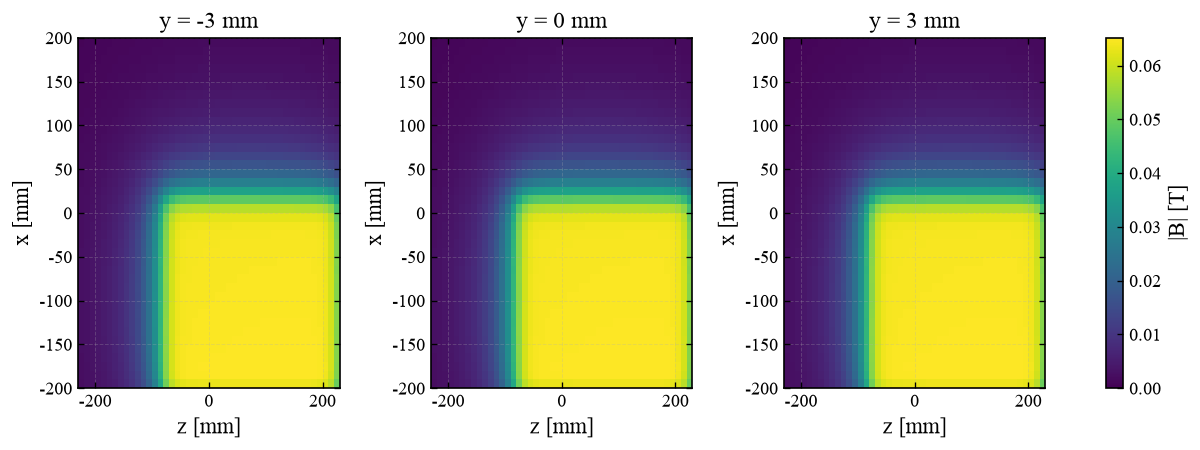

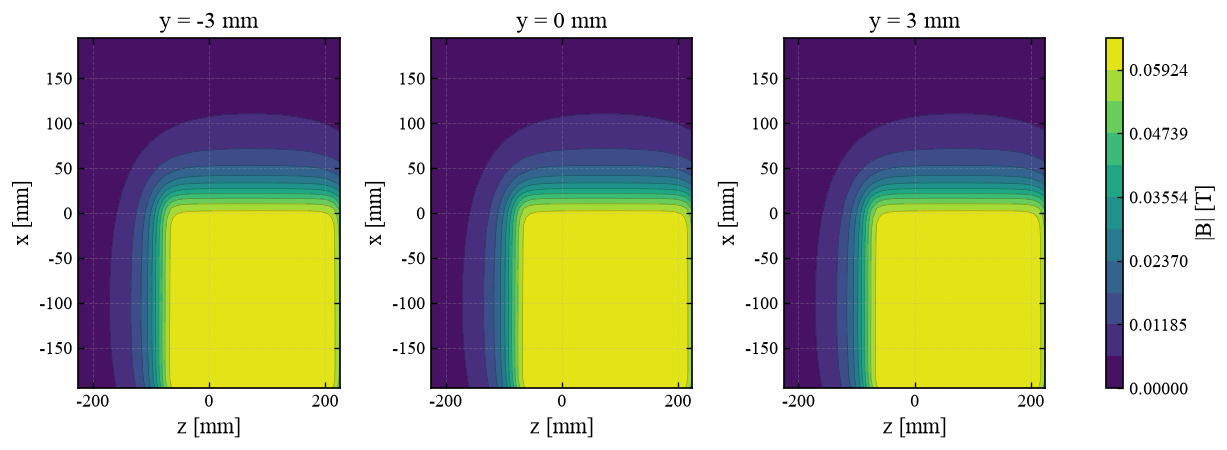

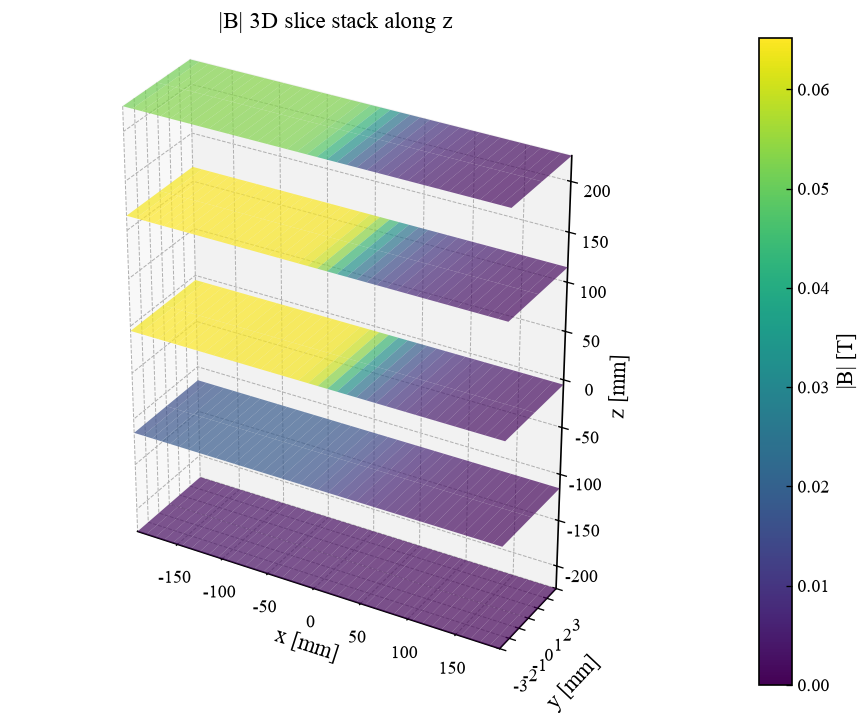

In [5]:
# ===== 3D 二极场可视化 (统一入口: 2D 剖面 / 填充等值线 / 半透明切片栈) =====
from astra_tools.plot.field_plots import plot_3d_field_map
plot_3d_field_map(work / "3D_Dipole", view="slices", plane="xz", n_slices=3);
plot_3d_field_map(work / "3D_Dipole", view="slices", kind="contour", plane="xz", n_slices=3);
plot_3d_field_map(work / "3D_Dipole", view="slices", n_slices=5);

束团粒子数: 7 (本例为探针轨迹演示, 粒子少是正常的)


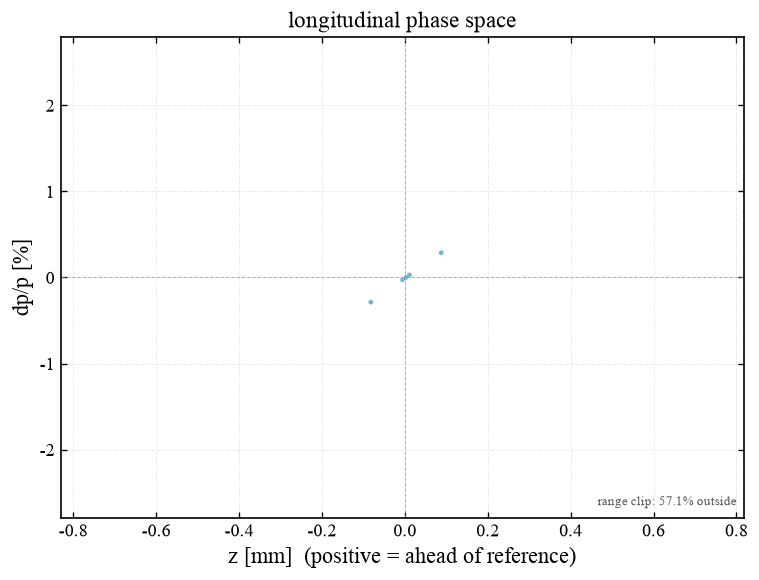

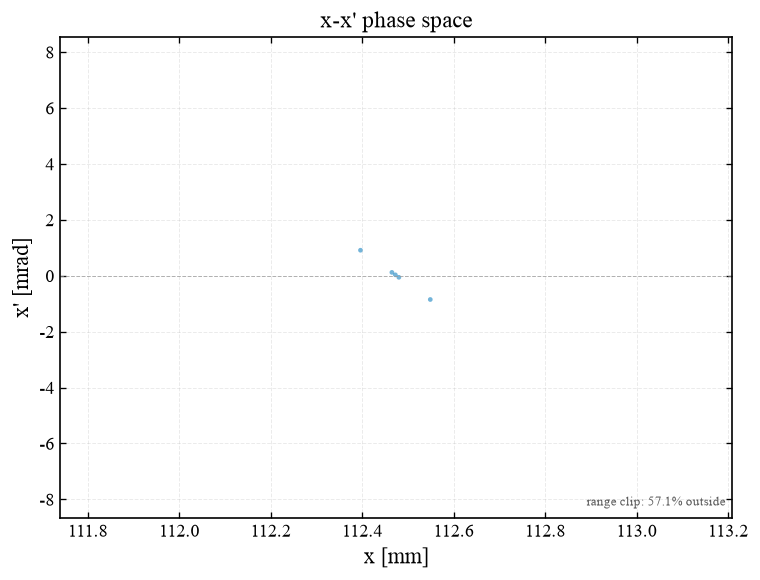

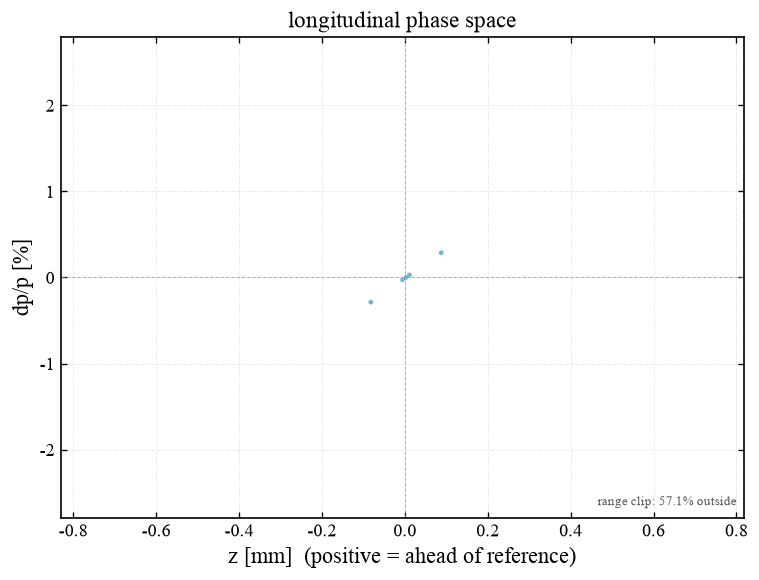

In [6]:
from astra_tools.plot.phase_space import plot_phase_space
print("束团粒子数:", dist.n_particle, "(本例为探针轨迹演示, 粒子少是正常的)")
plot_phase_space(dist, plane="x")
plot_phase_space(dist, plane="z")


In [7]:
log = (work / "Section2.Log.001").read_text().splitlines()
print("Section2 Log 末尾:")
for ln in log[-12:]:
    print(ln)


Section2 Log 末尾:
 STAT= 188*F,T,F,T,F,
 T,F,T,F,T,F,
 T,F,T,F,T,F,
  198*T,
 /
 End of Input deck
Section1.0100.001              -0.1360D-07  0.0000D+00  F
Section2.0079.001               5.4000D-01  0.0000D+00  F

     execution started:   19. 8.2026     21:34
     execution finished:  19. 8.2026     21:34
     execution time:  0.77 sek                         


In [8]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  末行比对 (new vs golden, log):
    finished        True       True       OK
其他官方算例的示例 notebook 同样位于 examples/ 目录
